# `^{171}Yb` Förster resonance 对已优化 UV CZ 序列的 branch-resolved Lindblad 评估

目标：沿用仓库已有的 no-jump 非厄密 GRAPE 优化结果作为控制序列，只在评估阶段加入文献约束的 near-branch Förster pair state，并使用完整 Lindblad 主方程传播密度矩阵。

本 notebook 的当前版本已经移除旧的错误模型。旧模型把 nearby Förster branch 写成 `V + Delta_F`，导致 pair eigenbranches 始终停留在强 blockade 能量附近，错误地给出“FR 几乎不影响 fidelity”的结论。当前模型使用

```math
H_{pair}=\begin{pmatrix}V_{bg} & W \\ W & \Delta_F\end{pmatrix},
```

其中 `Delta_F` 是相对 `|rr>` pair asymptote 的 Förster defect。Rydberg decay 也不再全部写入单一 absorbing `|loss>`，而是使用 Senoo et al. 2026 给出的 branch ratio 分解成 `^1S0`、`^3P2,F=3/2`、`m0`、`m1` 和 `other` sinks。


## 模型假设与待验证点

### 已固定的第一阶段假设

1. 控制序列来自 `artifacts/v5/closed_cr_edge_time_optimal_scan/rydberg_decay_65us_dense_selected_phase_rows.json`，即此前只考虑 Rydberg decay no-jump 的 phase-only optimized UV segment。
2. 训练优化阶段仍使用原 artifact；本 notebook 只做 post-optimization evaluation。
3. 评估阶段使用完整 Lindblad master equation，不用非厄密 effective generator 推断 FR 影响。
4. Förster branch 采用文献约束的 near-branch two-level pair model：`|rr>` 的背景 blockade energy 为 `V_bg`，nearby pair state `|b>` 的能量为 `Delta_F`。
5. Rydberg decay 使用 Senoo et al. 2026 Fig. 2d 的 branch ratios：`^1S0: 0.42`、`^3P2,F=3/2: 0.20`、`m0: 0.027`、`m1: 0.04`、`other: 0.31`。这些 source-data 数值总和为 `0.997`，collapse operators 内部归一化到总 decay rate `gamma`。

### 待验证点

1. 文献尺度 `Delta_F ~ 3 MHz`、`|Delta_F| < 10 MHz` 的 near-branch FR 是否显著降低当前 64-slot 序列的 projected probe fidelity。
2. FR excess infidelity 是否与 nearest pair eigenenergy 接近 `0 MHz` 且带有非零 `|rr>` overlap 同时出现。
3. branch-resolved decay population 中，detectable leakage-like 分支与 metastable repopulation-like 分支各占多少。
4. 若 corrected evaluation 显示明显退化，后续才考虑把 `|b>` 显式纳入 GRAPE 重新优化。


## 导入依赖

本 notebook 使用 NumPy/SciPy 直接构造 Liouvillian，避免在早期探索阶段引入额外接口。

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import json
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
from scipy.sparse.linalg import expm_multiply
from scipy.optimize import minimize_scalar

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src" / "neutral_yb").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))


## `gaussian_edge_envelope_from_times`

本地定义 Gaussian 上升/下降沿 envelope，避免 notebook 执行时依赖仓库包导入。


In [2]:
def gaussian_edge_envelope_from_times(
    num_tslots: int,
    total_time: float,
    edge_time: float,
    sigma_to_edge: float = 1.0 / 3.0,
) -> np.ndarray:
    duration = float(total_time)
    edge = float(edge_time)
    if edge <= 0.0:
        return np.ones(int(num_tslots), dtype=np.float64)
    edge = min(edge, 0.499 * duration)
    sigma = max(edge * float(sigma_to_edge), 1e-12)
    grid = (np.arange(int(num_tslots), dtype=np.float64) + 0.5) * duration / float(num_tslots)
    envelope = np.ones(int(num_tslots), dtype=np.float64)
    left = grid < edge
    right = grid > duration - edge
    edge_floor = np.exp(-0.5 * (edge / sigma) ** 2)
    if np.any(left):
        left_gaussian = np.exp(-0.5 * ((grid[left] - edge) / sigma) ** 2)
        envelope[left] = (left_gaussian - edge_floor) / max(1.0 - edge_floor, 1e-12)
    if np.any(right):
        right_gaussian = np.exp(-0.5 * ((grid[right] - (duration - edge)) / sigma) ** 2)
        envelope[right] = (right_gaussian - edge_floor) / max(1.0 - edge_floor, 1e-12)
    return np.clip(envelope, 0.0, 1.0)


## `load_selected_phase_rows`

读取已有 UV edge scan 选中相位序列 artifact，返回其中的 `rows` 列表。

In [3]:
def load_selected_phase_rows(path: str | Path) -> list[dict[str, object]]:
    with Path(path).open("r", encoding="utf-8") as handle:
        payload = json.load(handle)
    return list(payload["rows"])

## `select_control_row`

按 `(Omega_max, edge_ns)` 从 artifact rows 中选出一条已优化控制序列。

In [4]:
def select_control_row(
    rows: list[dict[str, object]],
    *,
    omega_max_mhz: float = 10.0,
    edge_ns: float = 40.0,
) -> dict[str, object]:
    matches = [
        row
        for row in rows
        if float(row["omega_max_mhz"]) == float(omega_max_mhz)
        and float(row["edge_ns"]) == float(edge_ns)
    ]
    if not matches:
        raise ValueError(f"No selected row for omega={omega_max_mhz} MHz, edge={edge_ns} ns")
    return matches[0]

## `ForsterLindbladConfig`

保存单条 Lindblad 评估所需参数，并提供无量纲时间步长、Rydberg decay rate、basis index 和 Senoo et al. 2026 branch ratios。


In [5]:
@dataclass(frozen=True)
class ForsterLindbladConfig:
    omega_max_mhz: float
    total_time_ns: float
    edge_time_ns: float
    num_tslots: int
    blockade_shift_mhz: float = 160.0
    rydberg_lifetime_s: float = 65e-6
    forster_defect_mhz: float = 3.0
    forster_coupling_mhz: float = 0.0

    @property
    def evo_time(self) -> float:
        return 2.0 * np.pi * self.omega_max_mhz * 1e6 * self.total_time_ns * 1e-9

    @property
    def dt(self) -> float:
        return self.evo_time / float(self.num_tslots)

    @property
    def gamma_over_omega(self) -> float:
        return 1.0 / (2.0 * np.pi * self.omega_max_mhz * 1e6 * self.rydberg_lifetime_s)


IDX_00 = 0
IDX_0C = 1
IDX_0R = 2
IDX_CC = 3
IDX_W_CR = 4
IDX_RR = 5
IDX_B = 6
IDX_SINK_1S0 = 7
IDX_SINK_3P2 = 8
IDX_SINK_M0 = 9
IDX_SINK_M1 = 10
IDX_SINK_OTHER = 11
HILBERT_DIMENSION = 12

ACTIVE_INDICES = np.array([IDX_00, IDX_0C, IDX_CC], dtype=np.int64)
ACTIVE_WEIGHTS = np.array([1.0, 2.0, 1.0], dtype=np.float64)
SINGLE_RYDBERG_INDICES = (IDX_0R, IDX_W_CR)
PAIR_RYDBERG_INDICES = (IDX_RR, IDX_B)
SINK_INDICES = {
    "1S0": IDX_SINK_1S0,
    "3P2_F32": IDX_SINK_3P2,
    "m0": IDX_SINK_M0,
    "m1": IDX_SINK_M1,
    "other": IDX_SINK_OTHER,
}
RAW_DECAY_BRANCH_RATIOS = {
    "1S0": 0.42,
    "3P2_F32": 0.20,
    "m0": 0.027,
    "m1": 0.04,
    "other": 0.31,
}
BRANCH_RATIO_SUM = float(sum(RAW_DECAY_BRANCH_RATIOS.values()))
DECAY_BRANCH_RATIOS = {
    branch: ratio / BRANCH_RATIO_SUM for branch, ratio in RAW_DECAY_BRANCH_RATIOS.items()
}
DETECTABLE_LEAKAGE_BRANCHES = ("1S0", "3P2_F32", "other")
METASTABLE_REPOPULATION_BRANCHES = ("m0", "m1")


## `add_quadrature_coupling`

按 phase-only control 约定向 `H_x/H_y` 中加入 Hermitian coupling。

In [6]:
def add_quadrature_coupling(h_x: np.ndarray, h_y: np.ndarray, left: int, right: int, strength: float) -> None:
    h_x[left, right] = strength
    h_x[right, left] = strength
    h_y[left, right] = -1j * strength
    h_y[right, left] = 1j * strength

## `jump_operator`

构造一个 Lindblad jump operator `sqrt(rate) |to><from|`。

In [7]:
def jump_operator(dimension: int, rate: float, to_index: int, from_index: int) -> np.ndarray:
    operator = np.zeros((dimension, dimension), dtype=np.complex128)
    if rate > 0.0:
        operator[to_index, from_index] = np.sqrt(rate)
    return operator

## 扩展 Hilbert basis

Basis ordering:

```text
0  |00>
1  |0c>
2  |0r>
3  |cc>
4  |W_cr>
5  |rr>
6  |b>          nearby Förster pair state
7  |sink_1S0>   Rydberg decay to ground state
8  |sink_3P2>   Rydberg decay to ^3P2,F=3/2
9  |sink_m0>    Rydberg decay/repopulation to metastable m0
10 |sink_m1>    Rydberg decay/repopulation to metastable m1
11 |sink_other> remaining measured Rydberg decay branches
```

计算子空间代表态仍使用 `|00>`, `|0c>`, `|cc>`，权重 `(1,2,1)` 展开回完整 4D computational diagonal。sink states 只记录 branch-resolved decay population，不被投回 active computational subspace。


## `build_hamiltonian_terms`

构造 drift Hamiltonian 与 UV quadrature Hamiltonians。当前 corrected Förster model 使用

```math
H_{pair}=\begin{pmatrix}V_{bg} & W \\ W & \Delta_F\end{pmatrix},
```

也就是说，`|b>` 的能量是相对 laser-resonant `|rr>` pair asymptote 的 defect `Delta_F`，不是 `V_bg + Delta_F`。这是和文献 near-branch Förster resonance 对齐的关键修正。


In [8]:
def build_hamiltonian_terms(config: ForsterLindbladConfig) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    h_d = np.zeros((HILBERT_DIMENSION, HILBERT_DIMENSION), dtype=np.complex128)
    h_x = np.zeros_like(h_d)
    h_y = np.zeros_like(h_d)

    blockade = config.blockade_shift_mhz / config.omega_max_mhz
    delta_f = config.forster_defect_mhz / config.omega_max_mhz
    coupling = config.forster_coupling_mhz / config.omega_max_mhz

    h_d[IDX_RR, IDX_RR] = blockade
    h_d[IDX_B, IDX_B] = delta_f
    h_d[IDX_RR, IDX_B] = coupling
    h_d[IDX_B, IDX_RR] = coupling

    add_quadrature_coupling(h_x, h_y, IDX_0C, IDX_0R, 0.5)
    add_quadrature_coupling(h_x, h_y, IDX_CC, IDX_W_CR, 1.0 / np.sqrt(2.0))
    add_quadrature_coupling(h_x, h_y, IDX_W_CR, IDX_RR, 1.0 / np.sqrt(2.0))
    return h_d, h_x, h_y


## `collapse_operators`

使用 Senoo et al. 2026 Fig. 2d 的 branch ratios 构造 state-resolved Rydberg decay jumps。source-data 数值总和为 `0.997`，这里归一化到总 decay rate `gamma`，避免因为四舍五入导致总 lifetime 改变。

single-Rydberg states 以 `gamma` decay；pair states `|rr>` 和 `|b>` 在 reduced model 中以 `2 gamma` decay 到同一组 branch sinks。


In [9]:
def collapse_operators(config: ForsterLindbladConfig) -> list[np.ndarray]:
    gamma = config.gamma_over_omega
    operators: list[np.ndarray] = []
    for branch, ratio in DECAY_BRANCH_RATIOS.items():
        sink = SINK_INDICES[branch]
        for source in SINGLE_RYDBERG_INDICES:
            operators.append(jump_operator(HILBERT_DIMENSION, gamma * ratio, sink, source))
        for source in PAIR_RYDBERG_INDICES:
            operators.append(jump_operator(HILBERT_DIMENSION, 2.0 * gamma * ratio, sink, source))
    return operators


## `liouvillian`

用 column-stacking convention 构造完整 Lindblad Liouvillian。

In [10]:
def liouvillian(hamiltonian: np.ndarray, c_ops: list[np.ndarray]) -> np.ndarray:
    dimension = hamiltonian.shape[0]
    identity = np.eye(dimension, dtype=np.complex128)
    generator = -1j * (np.kron(identity, hamiltonian) - np.kron(hamiltonian.T, identity))
    for collapse in c_ops:
        c_dagger_c = collapse.conj().T @ collapse
        generator += np.kron(collapse.conj(), collapse)
        generator -= 0.5 * np.kron(identity, c_dagger_c)
        generator -= 0.5 * np.kron(c_dagger_c.T, identity)
    return generator

## `vectorize_density`

把密度矩阵按 column-stacking 展平成 Liouville vector。

In [11]:
def vectorize_density(rho: np.ndarray) -> np.ndarray:
    return np.asarray(rho, dtype=np.complex128).reshape(-1, order="F")

## `unvectorize_density`

把 Liouville vector 还原为密度矩阵。

In [12]:
def unvectorize_density(vector: np.ndarray, dimension: int) -> np.ndarray:
    return np.asarray(vector, dtype=np.complex128).reshape((dimension, dimension), order="F")

## `propagate_density`

按已有 phase sequence 和 Gaussian edge envelope 对一态密度矩阵做完整 Lindblad 时序传播。

In [13]:
def propagate_density(config: ForsterLindbladConfig, phases: np.ndarray, rho0: np.ndarray) -> np.ndarray:
    h_d, h_x, h_y = build_hamiltonian_terms(config)
    c_ops = collapse_operators(config)
    envelope = gaussian_edge_envelope_from_times(
        config.num_tslots,
        config.total_time_ns,
        config.edge_time_ns,
        sigma_to_edge=1.0 / 3.0,
    )
    vector = vectorize_density(rho0)
    for amplitude, phase in zip(envelope, phases):
        hamiltonian = h_d + float(amplitude) * (np.cos(float(phase)) * h_x + np.sin(float(phase)) * h_y)
        vector = expm_multiply(config.dt * liouvillian(hamiltonian, c_ops), vector)
    return unvectorize_density(vector, h_d.shape[0])


## `propagate_density_vectors`

对多个初始密度矩阵向量同时传播；每个 time slot 只计算一次 Liouvillian matrix exponential。


In [14]:
def propagate_density_vectors(config: ForsterLindbladConfig, phases: np.ndarray, rho0_vectors: np.ndarray) -> np.ndarray:
    h_d, h_x, h_y = build_hamiltonian_terms(config)
    c_ops = collapse_operators(config)
    envelope = gaussian_edge_envelope_from_times(
        config.num_tslots,
        config.total_time_ns,
        config.edge_time_ns,
        sigma_to_edge=1.0 / 3.0,
    )
    vectors = np.asarray(rho0_vectors, dtype=np.complex128)
    for amplitude, phase in zip(envelope, phases):
        hamiltonian = h_d + float(amplitude) * (np.cos(float(phase)) * h_x + np.sin(float(phase)) * h_y)
        vectors = expm_multiply(config.dt * liouvillian(hamiltonian, c_ops), vectors)
    return vectors


## Fidelity 算法：branch-resolved Lindblad projected probe fidelity 与旧 no-jump process fidelity

当前 notebook 评估的是完整 Lindblad channel 后的 probe-state fidelity。令 active representative basis 为

$$
\mathcal{H}_a=\mathrm{span}\{|00\rangle,|0c\rangle,|cc\rangle\},
\quad P_a=\sum_{j\in a}|j\rangle\langle j|.
$$

对第 $m$ 个 probe 初态

$$
|\psi_m\rangle=a_m|00\rangle+b_m|0c\rangle+c_m|cc\rangle,
$$

完整主方程传播给出

$$
\rho_m(T)=\mathcal{E}_{\Delta_F,W}\left(|\psi_m\rangle\langle\psi_m|\right).
$$

目标相位门允许两个可优化 virtual-Z 相位 $\alpha,\beta$：

$$
U_{\rm targ}(\alpha,\beta)=
\mathrm{diag}\left(e^{i\alpha}, e^{i(\alpha+\beta)}, -e^{i(\alpha+2\beta)}\right)
$$

其中 `|0c>` 代表 `|0c>` 与 `|c0>` 两个对称 computational 分量的 reduced 描述。当前分数定义为

$$
F_{\rm probe}(\Delta_F,W)=
\max_{\alpha,\beta}\frac{1}{N_p}\sum_{m=1}^{N_p}
\langle\psi_m^{\rm targ}|P_a\rho_m(T)P_a|\psi_m^{\rm targ}\rangle,
\quad |\psi_m^{\rm targ}\rangle=U_{\rm targ}(\alpha,\beta)|\psi_m\rangle.
$$

这里 $N_p=4$，包含三条 basis probe 和一条 coherent superposition probe。注意这里**不按 surviving trace 重新归一化**，因此 population 泄漏到 Förster pair 或任意 decay sink 都会直接降低 fidelity。

旧 UV edge scan artifact 的优化口径不同：它使用 Rydberg decay 的 no-jump 非厄密生成元，取 reduced computational diagonal Kraus 元素

$$
z=(z_{00},z_{0c},z_{cc}),\quad w=(1,2,1),
$$

并计算

$$
F_{\rm pro}^{\rm no\ jump}=\frac{1}{16}\left|\sum_j w_j t_j^* z_j\right|^2,
\quad
P_{\rm active}^{\rm no\ jump}=\frac{1}{4}\sum_j w_j |z_j|^2,
$$

$$
F_{\rm avg}^{\rm no\ jump}=\frac{4F_{\rm pro}^{\rm no\ jump}+P_{\rm active}^{\rm no\ jump}}{5}.
$$

两者的关键差异是：旧口径只看 no-jump diagonal Kraus map，适合训练 phase-only 序列；当前口径对 Förster resonance 使用 trace-preserving Lindblad channel，可以显式包含 `|rr> <-> |b>` coherent mixing、branch-resolved Rydberg decay jumps 和 sink populations。


In [15]:
ACTIVE_INDICES = np.array([0, 1, 3], dtype=np.int64)
ACTIVE_WEIGHTS = np.array([1.0, 2.0, 1.0], dtype=np.float64)

## `active_ket`

把三维 active representative amplitudes 嵌入完整 8 维 Hilbert space。

In [16]:
def active_ket(amplitudes: list[complex]) -> np.ndarray:
    ket = np.zeros((HILBERT_DIMENSION, 1), dtype=np.complex128)
    for index, amplitude in zip(ACTIVE_INDICES, amplitudes):
        ket[index, 0] = amplitude
    return ket


## `target_active_ket`

给定 local phases `alpha,beta`，构造 reduced CZ target active ket。

In [17]:
def target_active_ket(amplitudes: list[complex], alpha: float, beta: float) -> np.ndarray:
    phases = np.array([np.exp(1j * alpha), np.exp(1j * (alpha + beta)), -np.exp(1j * (alpha + 2.0 * beta))])
    return active_ket((phases * np.asarray(amplitudes, dtype=np.complex128)).tolist())

## `representative_probe_amplitudes`

返回用于 projected fidelity 的三条 basis probe 和一条 coherent superposition probe。

In [18]:
def representative_probe_amplitudes() -> list[list[complex]]:
    return [
        [1.0, 0.0, 0.0],
        [0.0, 1.0, 0.0],
        [0.0, 0.0, 1.0],
        [0.5, 1.0 / np.sqrt(2.0), 0.5],
    ]

## `projected_probe_fidelity`

把 final density matrices 投影回 active subspace 后，与目标 probe states 求平均 fidelity。这个函数不对 `P rho P` 重新归一化，因此 Förster pair population 和所有 branch-resolved decay sinks 都作为 infidelity 进入结果。


In [19]:
def projected_probe_fidelity(final_rhos: list[np.ndarray], alpha: float, beta: float) -> float:
    projector = np.zeros((HILBERT_DIMENSION, HILBERT_DIMENSION), dtype=np.complex128)
    projector[ACTIVE_INDICES, ACTIVE_INDICES] = 1.0
    terms: list[float] = []
    for amplitudes, rho in zip(representative_probe_amplitudes(), final_rhos):
        target = target_active_ket(amplitudes, alpha, beta)
        projected = projector @ rho @ projector
        terms.append(float((target.conj().T @ projected @ target).real[0, 0]))
    return float(np.mean(terms))


## `evolve_probe_states`

对所有 representative probes 逐一做 Lindblad 时序传播。

In [20]:
def evolve_probe_states(config: ForsterLindbladConfig, phases: np.ndarray) -> list[np.ndarray]:
    initial_vectors: list[np.ndarray] = []
    for amplitudes in representative_probe_amplitudes():
        ket = active_ket(amplitudes)
        rho0 = ket @ ket.conj().T
        initial_vectors.append(vectorize_density(rho0))
    final_vectors = propagate_density_vectors(config, phases, np.column_stack(initial_vectors))
    return [unvectorize_density(final_vectors[:, index], HILBERT_DIMENSION) for index in range(final_vectors.shape[1])]


## `optimize_projected_phases`

先粗网格再单变量 refinement，寻找 projected probe fidelity 最优的 `alpha,beta`。

In [21]:
def optimize_projected_phases(final_rhos: list[np.ndarray]) -> tuple[float, float, float]:
    grid = np.linspace(-np.pi, np.pi, 41)
    best_alpha = 0.0
    best_beta = 0.0
    best_fidelity = -np.inf
    for alpha in grid:
        for beta in grid:
            fidelity = projected_probe_fidelity(final_rhos, float(alpha), float(beta))
            if fidelity > best_fidelity:
                best_alpha = float(alpha)
                best_beta = float(beta)
                best_fidelity = fidelity

    result_alpha = minimize_scalar(
        lambda value: -projected_probe_fidelity(final_rhos, float(value), best_beta),
        bounds=(best_alpha - 0.25, best_alpha + 0.25),
        method="bounded",
    )
    best_alpha = float(result_alpha.x)
    result_beta = minimize_scalar(
        lambda value: -projected_probe_fidelity(final_rhos, best_alpha, float(value)),
        bounds=(best_beta - 0.25, best_beta + 0.25),
        method="bounded",
    )
    best_beta = float(result_beta.x)
    best_fidelity = float(-result_beta.fun)
    return best_alpha, best_beta, best_fidelity

## `evaluate_row_lindblad`

输入一条已有 no-jump 优化行，在指定 Förster defect/coupling 下返回完整 branch-resolved Lindblad projected fidelity。

`mean_branch_population_*` 定义为四个 probe 初态演化后落入对应 decay sink 的人口平均值。完整 Lindblad 传播保持 `Tr rho = 1`，所以这些值不是 trace loss，而是已经发生 Rydberg decay 并按 Senoo et al. 2026 branch ratio 记录到各 sink 的概率。

为了避免在 reduced symmetric basis 中假装能还原完整 readout，当前只聚合两类物理量：

```math
p_{detectable}=p_{^1S0}+p_{^3P2}+p_{other},
\qquad
p_{metastable}=p_{m0}+p_{m1}.
```

前者更接近 detectable leakage / erasure-like 分支；后者是 metastable repopulation / spin-error-like 分支。它们都不是总 gate infidelity：coherent leakage 到 `|b>`、active subspace 相位误差、population 留在非目标 Rydberg 态也会影响 fidelity。


In [22]:
def pair_eigensystem_metrics(config: ForsterLindbladConfig) -> dict[str, float]:
    pair_hamiltonian_mhz = np.array(
        [
            [config.blockade_shift_mhz, config.forster_coupling_mhz],
            [config.forster_coupling_mhz, config.forster_defect_mhz],
        ],
        dtype=np.float64,
    )
    eigenvalues, eigenvectors = np.linalg.eigh(pair_hamiltonian_mhz)
    nearest_index = int(np.argmin(np.abs(eigenvalues)))
    lowest_index = int(np.argmin(eigenvalues))
    nearest_vector = eigenvectors[:, nearest_index]
    lowest_vector = eigenvectors[:, lowest_index]
    return {
        "nearest_pair_energy_mhz": float(eigenvalues[nearest_index]),
        "nearest_pair_target_overlap": float(abs(nearest_vector[0]) ** 2),
        "lowest_pair_energy_mhz": float(eigenvalues[lowest_index]),
        "lowest_pair_target_overlap": float(abs(lowest_vector[0]) ** 2),
    }


def branch_population_summary(final_rhos: list[np.ndarray]) -> dict[str, float]:
    summary: dict[str, float] = {}
    for branch, sink in SINK_INDICES.items():
        summary[f"mean_branch_population_{branch}"] = float(np.mean([rho[sink, sink].real for rho in final_rhos]))
    summary["mean_detectable_leakage_population"] = float(
        sum(summary[f"mean_branch_population_{branch}"] for branch in DETECTABLE_LEAKAGE_BRANCHES)
    )
    summary["mean_metastable_repopulation_population"] = float(
        sum(summary[f"mean_branch_population_{branch}"] for branch in METASTABLE_REPOPULATION_BRANCHES)
    )
    summary["mean_total_decay_population"] = float(
        sum(summary[f"mean_branch_population_{branch}"] for branch in SINK_INDICES)
    )
    return summary


def evaluate_row_lindblad(
    row: dict[str, object],
    *,
    forster_defect_mhz: float,
    forster_coupling_mhz: float,
) -> dict[str, float]:
    config = ForsterLindbladConfig(
        omega_max_mhz=float(row["omega_max_mhz"]),
        total_time_ns=float(row["total_time_ns"]),
        edge_time_ns=float(row["edge_ns"]),
        num_tslots=int(row["num_tslots"]),
        rydberg_lifetime_s=float(row["rydberg_lifetime_s"]),
        forster_defect_mhz=float(forster_defect_mhz),
        forster_coupling_mhz=float(forster_coupling_mhz),
    )
    phases = np.asarray(row["phases"], dtype=np.float64)
    final_rhos = evolve_probe_states(config, phases)
    alpha, beta, fidelity = optimize_projected_phases(final_rhos)
    trace_values = [float(np.trace(rho).real) for rho in final_rhos]
    result = {
        "projected_probe_fidelity": fidelity,
        "alpha": alpha,
        "beta": beta,
        "mean_trace": float(np.mean(trace_values)),
        "forster_defect_mhz": float(forster_defect_mhz),
        "forster_coupling_mhz": float(forster_coupling_mhz),
    }
    result.update(branch_population_summary(final_rhos))
    result.update(pair_eigensystem_metrics(config))
    return result


## `baseline_fidelity_comparison`

把同一条控制序列在旧 artifact 中保存的 no-jump 指标和当前完整 branch-resolved Lindblad projected probe 指标并列，避免把两种 fidelity 口径混在一起解释。


In [23]:
def baseline_fidelity_comparison(row: dict[str, object], lindblad_result: dict[str, float]) -> dict[str, float]:
    return {
        "artifact_process_fidelity": float(row["process_fidelity"]),
        "artifact_no_jump_average_fidelity": float(row["no_jump_average_fidelity"]),
        "artifact_active_population": float(row["active_population"]),
        "artifact_loss_proxy": float(row["loss_proxy"]),
        "lindblad_projected_probe_fidelity": float(lindblad_result["projected_probe_fidelity"]),
        "lindblad_mean_total_decay_population": float(lindblad_result["mean_total_decay_population"]),
        "lindblad_mean_detectable_leakage_population": float(lindblad_result["mean_detectable_leakage_population"]),
        "lindblad_mean_metastable_repopulation_population": float(
            lindblad_result["mean_metastable_repopulation_population"]
        ),
        "lindblad_minus_artifact_process": float(
            lindblad_result["projected_probe_fidelity"] - float(row["process_fidelity"])
        ),
        "lindblad_minus_artifact_no_jump_average": float(
            lindblad_result["projected_probe_fidelity"] - float(row["no_jump_average_fidelity"])
        ),
    }


## `control_waveform`

根据 artifact 中的 optimized phases 和 Gaussian edge envelope 还原实际用于传播的复 Rabi envelope。这里的 amplitude 单位是 `Omega/2pi` MHz；相位使用 unwrap 后的连续曲线展示。


In [24]:
def control_waveform(row: dict[str, object]) -> dict[str, np.ndarray]:
    phases = np.asarray(row["phases"], dtype=np.float64)
    total_time_ns = float(row["total_time_ns"])
    num_tslots = int(row["num_tslots"])
    times_ns = (np.arange(num_tslots, dtype=np.float64) + 0.5) * total_time_ns / float(num_tslots)
    envelope = gaussian_edge_envelope_from_times(
        num_tslots,
        total_time_ns,
        float(row["edge_ns"]),
        sigma_to_edge=1.0 / 3.0,
    )
    amplitude_mhz = float(row["omega_max_mhz"]) * envelope
    unwrapped_phase = np.unwrap(phases)
    complex_omega_mhz = amplitude_mhz * np.exp(1j * phases)
    return {
        "times_ns": times_ns,
        "amplitude_mhz": amplitude_mhz,
        "phase_rad": phases,
        "unwrapped_phase_rad": unwrapped_phase,
        "complex_omega_mhz": complex_omega_mhz,
    }


## `plot_control_waveform`

用两个子图展示 baseline 序列的 `Omega/2pi` amplitude 和相位随时间的变化，从图上直接确认是否包含上升/下降沿。


In [25]:
def plot_control_waveform(row: dict[str, object]) -> None:
    waveform = control_waveform(row)
    fig, axes = plt.subplots(2, 1, figsize=(8.6, 5.8), sharex=True)
    axes[0].plot(waveform["times_ns"], waveform["amplitude_mhz"], color="tab:blue", linewidth=2.0)
    axes[0].set_ylabel(r"$|\Omega(t)|/2\pi$ (MHz)")
    axes[0].set_title(
        rf"Baseline control: $\Omega_{{\max}}/2\pi={float(row['omega_max_mhz']):g}$ MHz, "
        rf"edge={float(row['edge_ns']):g} ns, T={float(row['total_time_ns']):g} ns"
    )
    axes[0].grid(True, alpha=0.30)

    axes[1].step(
        waveform["times_ns"],
        waveform["unwrapped_phase_rad"],
        where="mid",
        color="tab:orange",
        linewidth=1.8,
    )
    axes[1].set_xlabel("Time in UV segment (ns)")
    axes[1].set_ylabel(r"unwrap $\phi(t)$ (rad)")
    axes[1].grid(True, alpha=0.30)
    fig.tight_layout()
    plt.show()


## 读取默认 64-slot 控制序列并做 nominal branch-resolved Lindblad 检查

默认读取 `Omega_max/2pi = 10 MHz`, `edge_ns = 40 ns` 的 64-slot artifact。Nominal baseline 使用 corrected model 但令 `W=0`，因此 `Delta_F` 不影响动力学；这里取文献尺度 `Delta_F=3 MHz`。


In [26]:
artifact_path = PROJECT_ROOT / "artifacts/v5/closed_cr_edge_time_optimal_scan/rydberg_decay_65us_dense_selected_phase_rows.json"
rows = load_selected_phase_rows(artifact_path)
row = select_control_row(rows, omega_max_mhz=10.0, edge_ns=40.0)
nominal = evaluate_row_lindblad(row, forster_defect_mhz=3.0, forster_coupling_mhz=0.0)
baseline_comparison = baseline_fidelity_comparison(row, nominal)
print("Raw Senoo 2026 branch-ratio sum:", f"{BRANCH_RATIO_SUM:.3f}")
print(json.dumps(baseline_comparison, indent=2, sort_keys=True))


Raw Senoo 2026 branch-ratio sum: 0.997
{
  "artifact_active_population": 0.9992810722562444,
  "artifact_loss_proxy": 0.000718927743755593,
  "artifact_no_jump_average_fidelity": 0.9992810330578695,
  "artifact_process_fidelity": 0.999281023258276,
  "lindblad_mean_detectable_leakage_population": 0.0006220833782055415,
  "lindblad_mean_metastable_repopulation_population": 4.481675950513043e-05,
  "lindblad_mean_total_decay_population": 0.0006669001377106719,
  "lindblad_minus_artifact_no_jump_average": -0.0007985803914331013,
  "lindblad_minus_artifact_process": -0.0007985705918395203,
  "lindblad_projected_probe_fidelity": 0.9984824526664364
}


## 当前采用的 64-slot 控制波形

下面直接使用默认 64-slot artifact 画最终采用的 `Omega` amplitude 和 phase 随时间变化。


Active control row: num_tslots=64, T=170 ns, edge=40 ns, F_process_nojump=0.9992810233


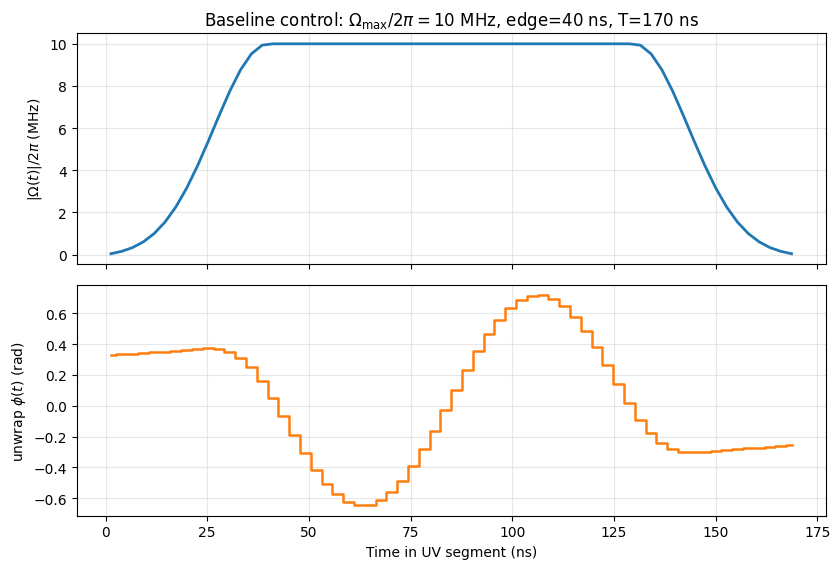

In [27]:
active_control_row = row
print(
    f"Active control row: num_tslots={int(active_control_row['num_tslots'])}, "
    f"T={float(active_control_row['total_time_ns']):.0f} ns, "
    f"edge={float(active_control_row['edge_ns']):.0f} ns, "
    f"F_process_nojump={float(active_control_row['process_fidelity']):.10f}"
)
plot_control_waveform(active_control_row)


## `scan_forster_grid`

扫描只改变 `Delta_F` 和 `W`，不重新优化控制。`Delta_F` 的 MHz 级区域对应 small Förster defect 风险；这里用完整 Lindblad 主方程逐点评估。


In [28]:
def scan_forster_grid(
    row: dict[str, object],
    *,
    defects_mhz: np.ndarray,
    couplings_mhz: np.ndarray,
) -> list[dict[str, float]]:
    results: list[dict[str, float]] = []
    for coupling in couplings_mhz:
        for defect in defects_mhz:
            results.append(
                evaluate_row_lindblad(
                    row,
                    forster_defect_mhz=float(defect),
                    forster_coupling_mhz=float(coupling),
                )
            )
    return results

## `scan_result_matrix`

把 `scan_forster_grid` 的 list-of-dicts 结果整理成 `coupling x defect` 矩阵，便于画 heatmap 和查看 resonance dip。


In [29]:
def scan_result_matrix(
    results: list[dict[str, float]],
    *,
    defects_mhz: np.ndarray,
    couplings_mhz: np.ndarray,
    metric: str,
) -> np.ndarray:
    matrix = np.full((len(couplings_mhz), len(defects_mhz)), np.nan, dtype=np.float64)
    for result in results:
        defect_index = int(np.where(np.isclose(defects_mhz, result["forster_defect_mhz"]))[0][0])
        coupling_index = int(np.where(np.isclose(couplings_mhz, result["forster_coupling_mhz"]))[0][0])
        matrix[coupling_index, defect_index] = float(result[metric])
    return matrix


## `print_scan_summary`

打印每个 `W` 下最差 fidelity 的位置，以及 corrected pair model 的 nearest laser branch 指标。矩阵行是 `W`，列是 `Delta_F`。


In [30]:
def print_scan_summary(
    defects_mhz: np.ndarray,
    couplings_mhz: np.ndarray,
    fidelity_matrix: np.ndarray,
    nearest_energy_matrix: np.ndarray,
    overlap_matrix: np.ndarray,
) -> None:
    print("Worst point for each W:")
    for row_index, coupling in enumerate(couplings_mhz):
        worst_index = int(np.nanargmin(fidelity_matrix[row_index]))
        print(
            f"  W={coupling:4.1f} MHz: "
            f"min F={fidelity_matrix[row_index, worst_index]:.10f} "
            f"at Delta_F={defects_mhz[worst_index]:5.1f} MHz; "
            f"nearest E={nearest_energy_matrix[row_index, worst_index]:+.3f} MHz, "
            f"|<rr|e>|^2={overlap_matrix[row_index, worst_index]:.3e}"
        )
    print("\nProjected probe fidelity matrix, rows W MHz, columns Delta_F MHz:")
    print("Delta_F:", " ".join(f"{defect:>9.1f}" for defect in defects_mhz))
    for row_index, coupling in enumerate(couplings_mhz):
        values = " ".join(f"{value:9.7f}" for value in fidelity_matrix[row_index])
        print(f"W={coupling:4.1f}: {values}")


## `forster_excess_infidelity_matrix`

从 absolute projected fidelity 中扣掉同一 `Delta_F` 下 `W=0` 的无 FR baseline，提取打开 Förster coupling 后额外增加的 infidelity。

$$
\Delta I_{\rm FR}(\Delta_F,W)
= [1-F(\Delta_F,W)]-[1-F(\Delta_F,0)]
=F(\Delta_F,0)-F(\Delta_F,W).
$$

由于 `W=0` 时 `|rr>` 与 `|b>` 解耦，`Delta_F` 只改变未占据的 `|b>` 能量，理论上 baseline 应与 `Delta_F` 无关；按列相减可以同时抵消微小数值漂移。


In [31]:
def forster_excess_infidelity_matrix(fidelity_matrix: np.ndarray, couplings_mhz: np.ndarray) -> np.ndarray:
    baseline_index = int(np.where(np.isclose(couplings_mhz, 0.0))[0][0])
    baseline_fidelity = fidelity_matrix[baseline_index : baseline_index + 1, :]
    return baseline_fidelity - fidelity_matrix


## `print_forster_excess_summary`

用一般科学计数法打印 FR 额外 infidelity。数值保持为无量纲 infidelity 差值。


In [32]:
def print_forster_excess_summary(
    defects_mhz: np.ndarray,
    couplings_mhz: np.ndarray,
    excess_infidelity: np.ndarray,
) -> None:
    print("FR excess infidelity relative to W=0 baseline:")
    for row_index, coupling in enumerate(couplings_mhz):
        worst_index = int(np.nanargmax(excess_infidelity[row_index]))
        print(
            f"  W={coupling:4.1f} MHz: "
            f"max excess={excess_infidelity[row_index, worst_index]:.3e} "
            f"at Delta_F={defects_mhz[worst_index]:5.1f} MHz"
        )
    print("\nFR excess infidelity matrix, rows W MHz, columns Delta_F MHz:")
    print("Delta_F:", " ".join(f"{defect:>10.1f}" for defect in defects_mhz))
    for row_index, coupling in enumerate(couplings_mhz):
        values = " ".join(f"{value:10.3e}" for value in excess_infidelity[row_index])
        print(f"W={coupling:4.1f}: {values}")


## `plot_forster_scan_heatmaps`

四张 heatmap 分别显示：absolute projected probe infidelity、相对 `W=0` baseline 的 FR excess infidelity、nearest pair eigenenergy、以及该 nearest eigenbranch 的 target-pair overlap。第三和第四张图用于判断 fidelity dip 是否真来自接近 laser resonance 且带有 `|rr>` overlap 的 pair branch。


In [33]:
def plot_forster_scan_heatmaps(
    defects_mhz: np.ndarray,
    couplings_mhz: np.ndarray,
    fidelity_matrix: np.ndarray,
    excess_infidelity: np.ndarray,
    nearest_energy_matrix: np.ndarray,
    overlap_matrix: np.ndarray,
) -> None:
    extent = [
        float(defects_mhz[0]),
        float(defects_mhz[-1]),
        float(couplings_mhz[0]),
        float(couplings_mhz[-1]),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(12.8, 8.2), sharex=True, sharey=True)
    axes_flat = axes.ravel()
    infidelity = 1.0 - fidelity_matrix

    im0 = axes_flat[0].imshow(infidelity, origin="lower", aspect="auto", extent=extent, cmap="magma")
    axes_flat[0].set_title(r"Absolute probe infidelity")
    fig.colorbar(im0, ax=axes_flat[0], label=r"$1-F_{probe}$")

    im1 = axes_flat[1].imshow(excess_infidelity, origin="lower", aspect="auto", extent=extent, cmap="cividis")
    axes_flat[1].set_title("FR excess infidelity")
    fig.colorbar(im1, ax=axes_flat[1], label="excess over W=0")

    im2 = axes_flat[2].imshow(nearest_energy_matrix, origin="lower", aspect="auto", extent=extent, cmap="coolwarm")
    axes_flat[2].set_title("Nearest pair eigenenergy")
    fig.colorbar(im2, ax=axes_flat[2], label="MHz")

    im3 = axes_flat[3].imshow(overlap_matrix, origin="lower", aspect="auto", extent=extent, cmap="viridis")
    axes_flat[3].set_title(r"Nearest branch $|rr|$ overlap")
    fig.colorbar(im3, ax=axes_flat[3], label=r"$|\langle rr|e\rangle|^2$")

    for axis in axes_flat:
        axis.axvline(0.0, color="white", linestyle="--", linewidth=1.0, alpha=0.75)
        axis.axvline(3.0, color="white", linestyle=":", linewidth=1.0, alpha=0.75)
        axis.set_xlabel(r"$\Delta_F$ (MHz)")
        axis.set_ylabel(r"$W$ (MHz)")
    fig.tight_layout()
    plt.show()


## Corrected `Delta_F x W` 扫描

本节使用 corrected near-branch Förster model：`|b>` 的能量为 `Delta_F`，不再是 `V + Delta_F`。主扫描聚焦文献尺度：`Delta_F = -20, -10, -5, -3, 0, 3, 5, 10, 20 MHz`，并扫描 `W = 0, 1, 2, 5, 10, 20 MHz`。这个网格覆盖 Peper et al. 2025 给出的 `Delta_F ~ 3 MHz` 和 `|Delta_F| < 10 MHz` 风险区，同时保持 notebook 可重复执行。

输出同时给出 absolute infidelity、扣掉同一 `Delta_F` 下 `W=0` baseline 后的 FR excess infidelity、nearest pair eigenenergy 和 target-pair overlap。


Corrected FR scan control row: num_tslots=64, T=170 ns
Worst point for each W:
  W= 0.0 MHz: min F=0.9984824527 at Delta_F=-10.0 MHz; nearest E=-10.000 MHz, |<rr|e>|^2=0.000e+00
  W= 1.0 MHz: min F=0.9983244104 at Delta_F=  3.0 MHz; nearest E=+2.994 MHz, |<rr|e>|^2=4.056e-05
  W= 2.0 MHz: min F=0.9978510471 at Delta_F=  3.0 MHz; nearest E=+2.975 MHz, |<rr|e>|^2=1.622e-04
  W= 5.0 MHz: min F=0.9945723393 at Delta_F=  3.0 MHz; nearest E=+2.841 MHz, |<rr|e>|^2=1.011e-03
  W=10.0 MHz: min F=0.9834373871 at Delta_F=  5.0 MHz; nearest E=+4.358 MHz, |<rr|e>|^2=4.111e-03
  W=20.0 MHz: min F=0.9414782546 at Delta_F=  5.0 MHz; nearest E=+2.461 MHz, |<rr|e>|^2=1.586e-02

Projected probe fidelity matrix, rows W MHz, columns Delta_F MHz:
Delta_F:     -20.0     -10.0      -5.0      -3.0       0.0       3.0       5.0      10.0      20.0
W= 0.0: 0.9984825 0.9984825 0.9984825 0.9984825 0.9984825 0.9984825 0.9984825 0.9984825 0.9984825
W= 1.0: 0.9984826 0.9984811 0.9984760 0.9984527 0.9983806 0.9983244 

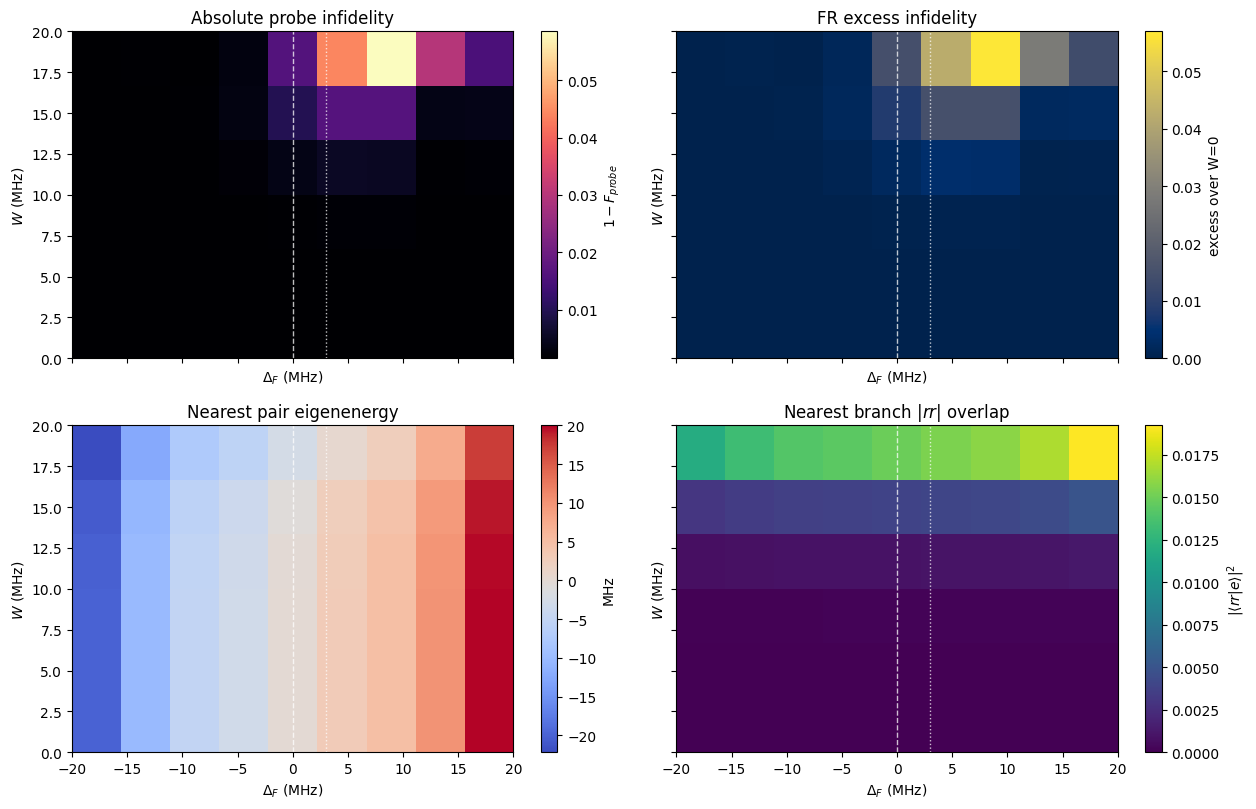

In [34]:
forster_scan_row = active_control_row
defects_mhz = np.array([-20.0, -10.0, -5.0, -3.0, 0.0, 3.0, 5.0, 10.0, 20.0])
couplings_mhz = np.array([0.0, 1.0, 2.0, 5.0, 10.0, 20.0])
scan_results = scan_forster_grid(forster_scan_row, defects_mhz=defects_mhz, couplings_mhz=couplings_mhz)
fidelity_matrix = scan_result_matrix(
    scan_results,
    defects_mhz=defects_mhz,
    couplings_mhz=couplings_mhz,
    metric="projected_probe_fidelity",
)
total_decay_matrix = scan_result_matrix(
    scan_results,
    defects_mhz=defects_mhz,
    couplings_mhz=couplings_mhz,
    metric="mean_total_decay_population",
)
detectable_matrix = scan_result_matrix(
    scan_results,
    defects_mhz=defects_mhz,
    couplings_mhz=couplings_mhz,
    metric="mean_detectable_leakage_population",
)
metastable_matrix = scan_result_matrix(
    scan_results,
    defects_mhz=defects_mhz,
    couplings_mhz=couplings_mhz,
    metric="mean_metastable_repopulation_population",
)
nearest_energy_matrix = scan_result_matrix(
    scan_results,
    defects_mhz=defects_mhz,
    couplings_mhz=couplings_mhz,
    metric="nearest_pair_energy_mhz",
)
overlap_matrix = scan_result_matrix(
    scan_results,
    defects_mhz=defects_mhz,
    couplings_mhz=couplings_mhz,
    metric="nearest_pair_target_overlap",
)
excess_infidelity_matrix = forster_excess_infidelity_matrix(fidelity_matrix, couplings_mhz)
print(f"Corrected FR scan control row: num_tslots={int(forster_scan_row['num_tslots'])}, T={float(forster_scan_row['total_time_ns']):.0f} ns")
print_scan_summary(defects_mhz, couplings_mhz, fidelity_matrix, nearest_energy_matrix, overlap_matrix)
print()
print_forster_excess_summary(defects_mhz, couplings_mhz, excess_infidelity_matrix)
print("\nBranch-resolved decay populations at worst corrected-FR point:")
worst_flat_index = int(np.nanargmin(fidelity_matrix))
worst_coupling_index, worst_defect_index = np.unravel_index(worst_flat_index, fidelity_matrix.shape)
worst_result = next(
    result for result in scan_results
    if np.isclose(result["forster_coupling_mhz"], couplings_mhz[worst_coupling_index])
    and np.isclose(result["forster_defect_mhz"], defects_mhz[worst_defect_index])
)
for key in [
    "mean_branch_population_1S0",
    "mean_branch_population_3P2_F32",
    "mean_branch_population_m0",
    "mean_branch_population_m1",
    "mean_branch_population_other",
    "mean_detectable_leakage_population",
    "mean_metastable_repopulation_population",
    "mean_total_decay_population",
]:
    print(f"  {key}: {worst_result[key]:.6e}")
plot_forster_scan_heatmaps(
    defects_mhz,
    couplings_mhz,
    fidelity_matrix,
    excess_infidelity_matrix,
    nearest_energy_matrix,
    overlap_matrix,
)


## 热力图各面板的物理意义

横轴是 Förster defect `Delta_F`，即 nearby pair state `|b>` 相对 laser-resonant `|rr>` pair asymptote 的能量失谐；纵轴是 `|rr> <-> |b>` 的 effective coupling `W`。每个格子都表示在同一条 64-slot UV 控制序列下，用完整 branch-resolved Lindblad 主方程重新传播得到的结果。

左上角 `Absolute probe infidelity` 显示

```math
1-F_{probe}(\Delta_F,W),
```

包含所有来源的误差：baseline Rydberg decay、active subspace 相位误差、coherent leakage 到 `|b>`、以及 branch-resolved decay sinks。因此它不是纯 FR 误差，而是该参数点下的总 projected probe infidelity。

右上角 `FR excess infidelity` 显示

```math
\Delta I_{FR}(\Delta_F,W)=F_{probe}(\Delta_F,0)-F_{probe}(\Delta_F,W),
```

也就是打开 Förster coupling `W` 后相对同一 `Delta_F`、`W=0` baseline 额外增加的 infidelity。这个 panel 是判断 Förster resonance 本身对门误差贡献的主图。

左下角 `Nearest pair eigenenergy` 是 corrected pair Hamiltonian

```math
H_{pair}=\begin{pmatrix}V_{bg} & W \\ W & \Delta_F\end{pmatrix}
```

中最接近 laser resonance 的 pair eigenenergy。数值越接近 `0 MHz`，说明存在越接近共振的 pair branch，越可能破坏 blockade。

右下角 `Nearest branch |rr| overlap` 是这条最近共振 eigenbranch 中 target pair state `|rr>` 的权重

```math
|\langle rr|e_{near}\rangle|^2.
```

只有当 nearest eigenenergy 接近 `0 MHz` 且该 overlap 非零时，UV pulse 才能有效把 population 通过 `|rr>` 成分耦合到 near-resonant pair branch。也就是说，真正危险的区域不是单独由小 `Delta_F` 或大 `W` 决定，而是由“near-zero pair eigenenergy + finite `|rr>` overlap”共同决定。


## 修正后的结果解读

1. 旧的 `V + Delta_F` Förster branch 模型已经移除；当前 notebook 只使用 near-branch corrected model。
2. 单一 absorbing `|loss>` 已经替换为 Senoo et al. 2026 branch-resolved sinks。Nominal `W=0` baseline 的总 Rydberg-decay sink population 为 `6.669e-4`，其中 detectable leakage-like branches 为 `6.221e-4`，metastable repopulation-like branches 为 `4.482e-5`。
3. corrected scan 不再支持“FR 几乎不影响 fidelity”的结论。在文献尺度附近，`W=5 MHz, Delta_F=3 MHz` 给出 FR excess infidelity `3.910e-3`；`W=10 MHz` 时最大 excess 达到 `1.505e-2`；`W=20 MHz` 时最大 excess 达到 `5.700e-2`。
4. worst corrected-FR point 的 total decay population 仍只有 `7.666e-4`，说明大部分新增 infidelity 来自 near-resonant pair branch 导致的 coherent blockade violation / phase error，而不是 branch-resolved spontaneous decay 本身。
5. 当前 scan 的 `W=0` 行仍是 no-FR baseline；`W>0` 行给出同一 `Delta_F` 下打开 FR coupling 后的 excess infidelity。若后续要优化 pulse，应把 `|b>` 和 branch-resolved decay 纳入优化目标，而不是继续用单 blockade shift 训练。
